In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load Data and Initial Inspection

In [2]:
# Load the training dataset
df_train = pd.read_csv('/content/train.csv')

# Display the first 5 rows of the DataFrame
print('First 5 rows of the dataset:')
display(df_train.head())

First 5 rows of the dataset:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Get a concise summary of the DataFrame, including data types and non-null values
print('\nDataFrame Info:')
df_train.info()


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
# Generate descriptive statistics that summarize the central tendency, dispersion, and shape of a dataset's distribution
print('\nDescriptive statistics for numerical columns:')
display(df_train.describe())


Descriptive statistics for numerical columns:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 2. Exploratory Data Analysis (EDA) - Visualizations

### Pairplot of Numerical Features

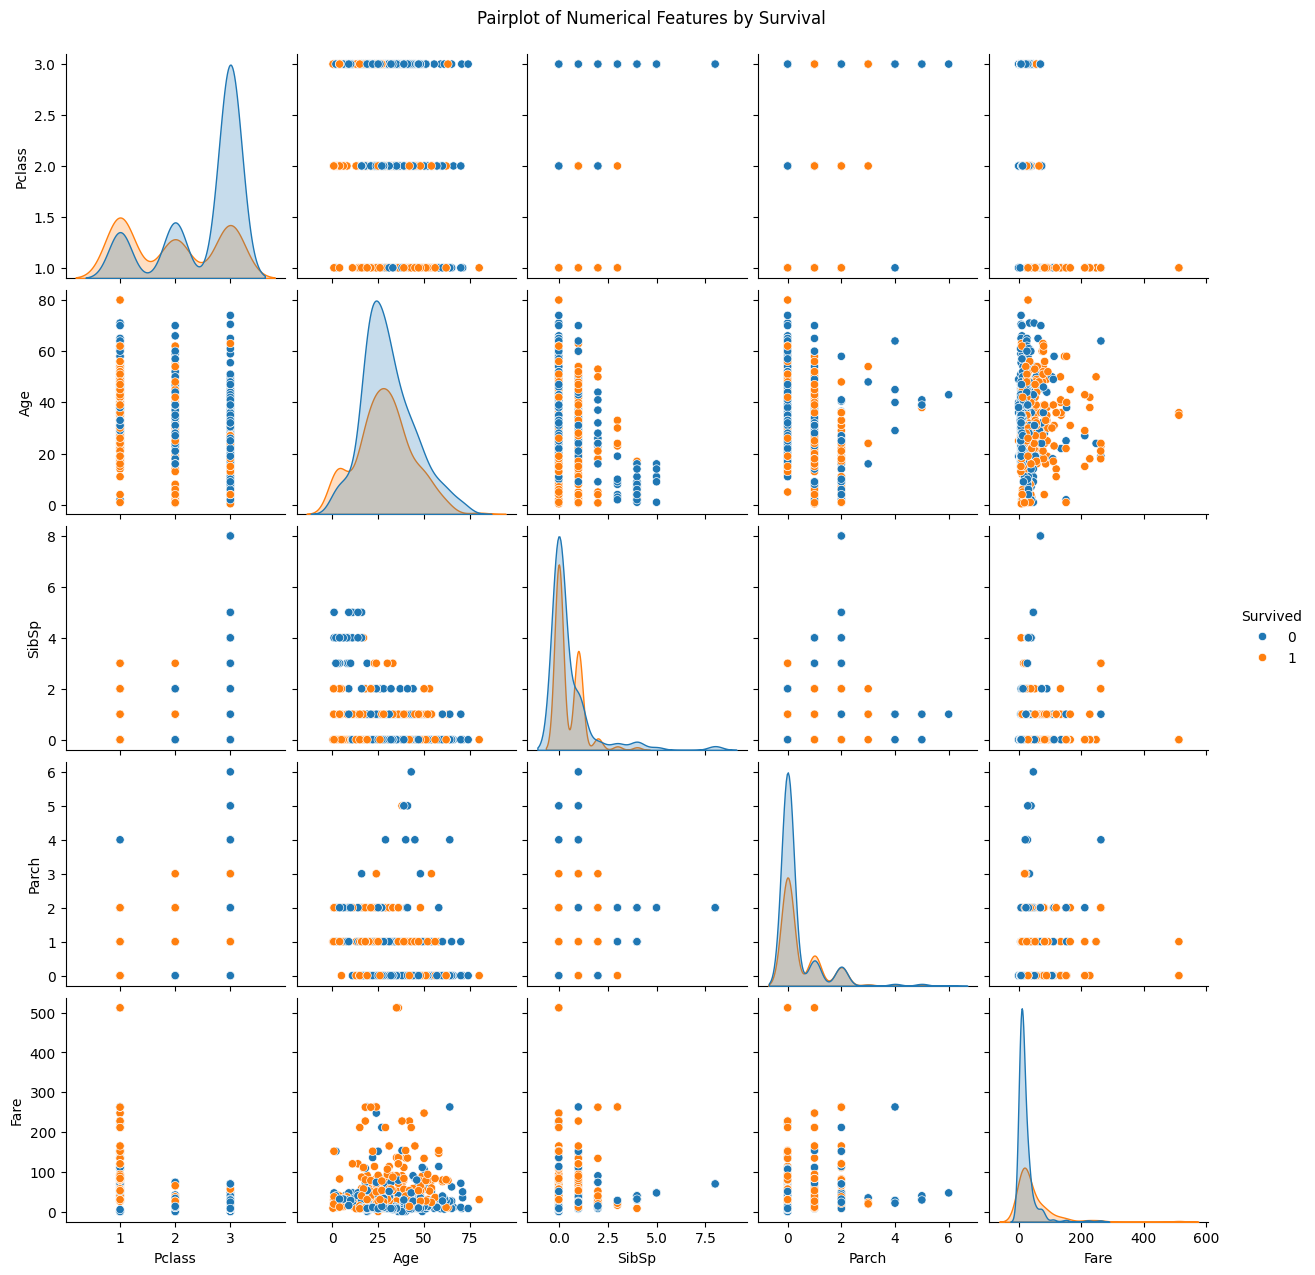

In [7]:
sns.pairplot(df_train[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']], hue='Survived')
plt.suptitle('Pairplot of Numerical Features by Survival', y=1.02)
plt.show()

### Correlation Heatmap

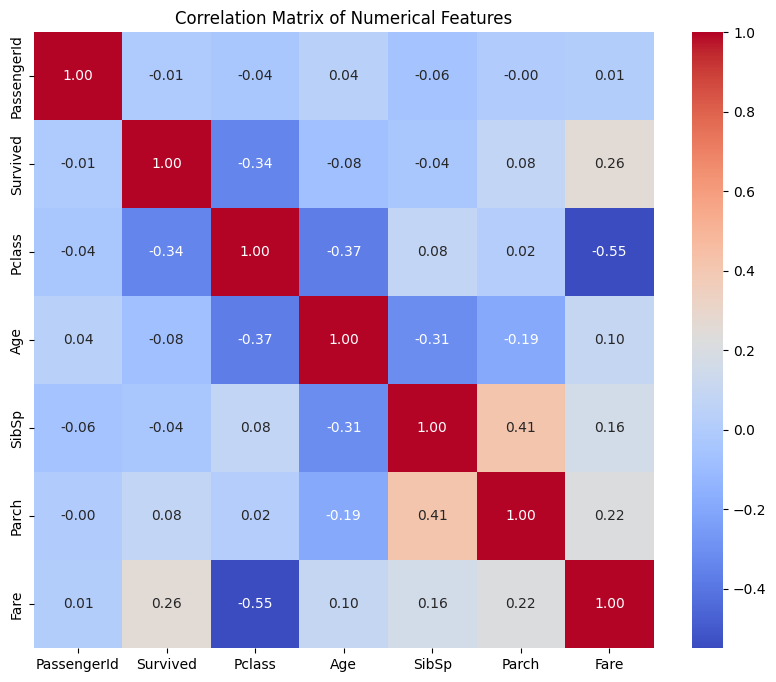

In [8]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_train.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Value Counts for Categorical Columns

In [6]:
print('\nValue counts for "Survived":')
display(df_train['Survived'].value_counts())

print('\nValue counts for "Pclass":')
display(df_train['Pclass'].value_counts())

print('\nValue counts for "Sex":')
display(df_train['Sex'].value_counts())

print('\nValue counts for "Embarked":')
display(df_train['Embarked'].value_counts())


Value counts for "Survived":


,count
Survived,
0,549
1,342



Value counts for "Pclass":


,count
Pclass,
3,491
1,216
2,184



Value counts for "Sex":


,count
Sex,
male,577
female,314



Value counts for "Embarked":


,count
Embarked,
S,644
C,168
Q,77


### Value Counts for Categorical Columns

In [9]:
print('\nValue counts for "Survived":')
display(df_train['Survived'].value_counts())

print('\nValue counts for "Pclass":')
display(df_train['Pclass'].value_counts())


Value counts for "Survived":


,count
Survived,
0,549
1,342



Value counts for "Pclass":


,count
Pclass,
3,491
1,216
2,184


In [10]:
print('\nValue counts for "Sex":')
display(df_train['Sex'].value_counts())


Value counts for "Sex":


,count
Sex,
male,577
female,314


In [11]:
print('\nValue counts for "Embarked":')
display(df_train['Embarked'].value_counts())


Value counts for "Embarked":


,count
Embarked,
S,644
C,168
Q,77


### Histograms of Numerical Features

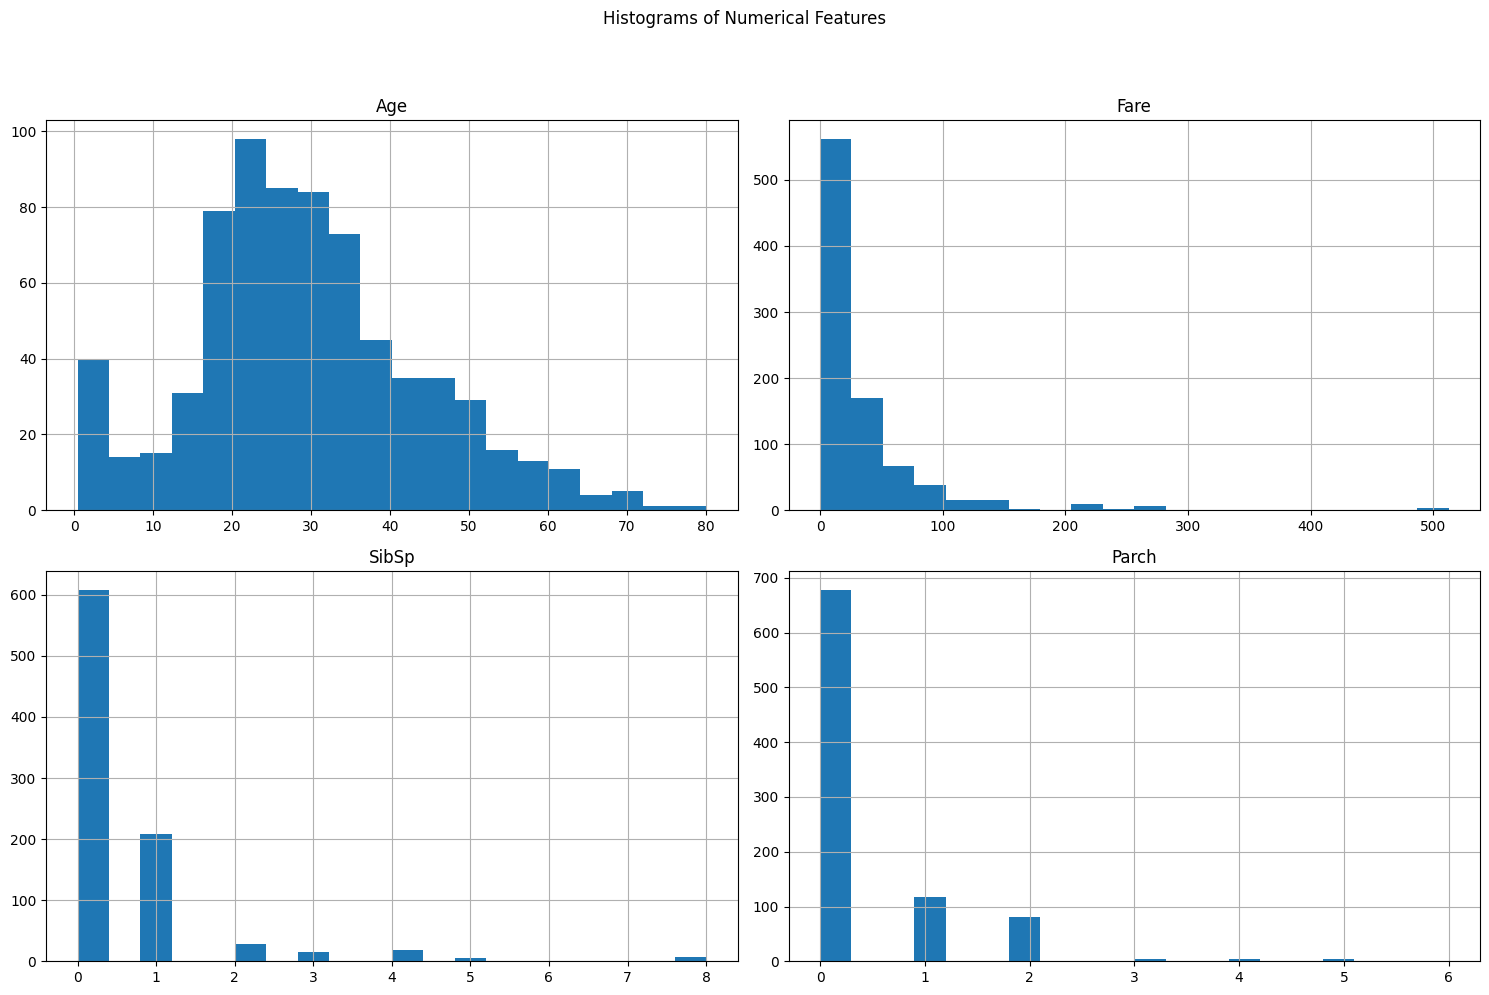

In [15]:
df_train[['Age', 'Fare', 'SibSp', 'Parch']].hist(bins=20, figsize=(15, 10))
plt.suptitle('Histograms of Numerical Features', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

### Boxplots of Numerical Features by Survival

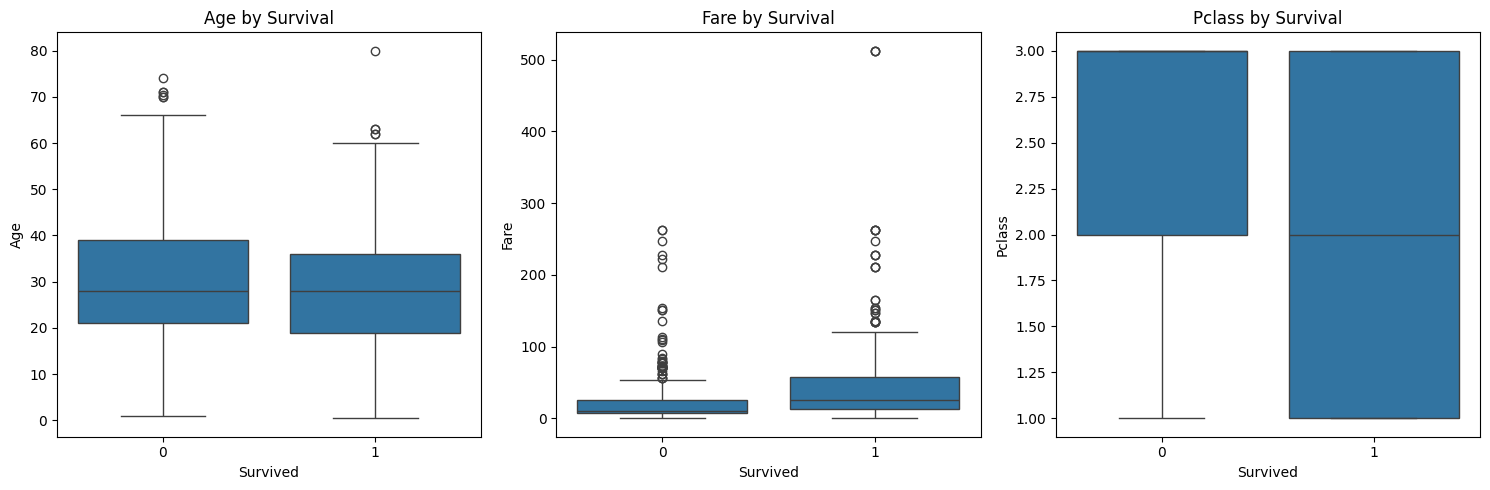

In [16]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.boxplot(x='Survived', y='Age', data=df_train)
plt.title('Age by Survival')

plt.subplot(1, 3, 2)
sns.boxplot(x='Survived', y='Fare', data=df_train)
plt.title('Fare by Survival')

plt.subplot(1, 3, 3)
sns.boxplot(x='Survived', y='Pclass', data=df_train)
plt.title('Pclass by Survival')

plt.tight_layout()
plt.show()

### Scatterplot: Age vs. Fare by Survival

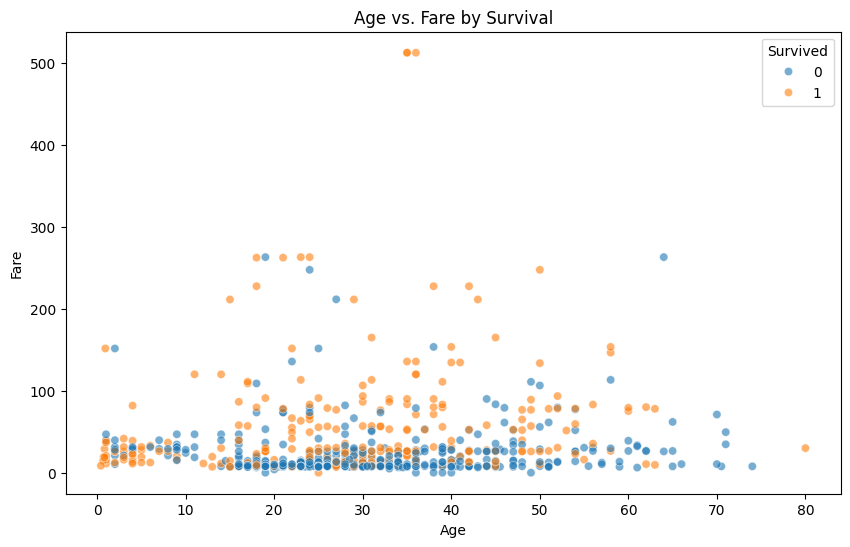

In [17]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=df_train, alpha=0.6)
plt.title('Age vs. Fare by Survival')
plt.show()

### Histograms of Numerical Features

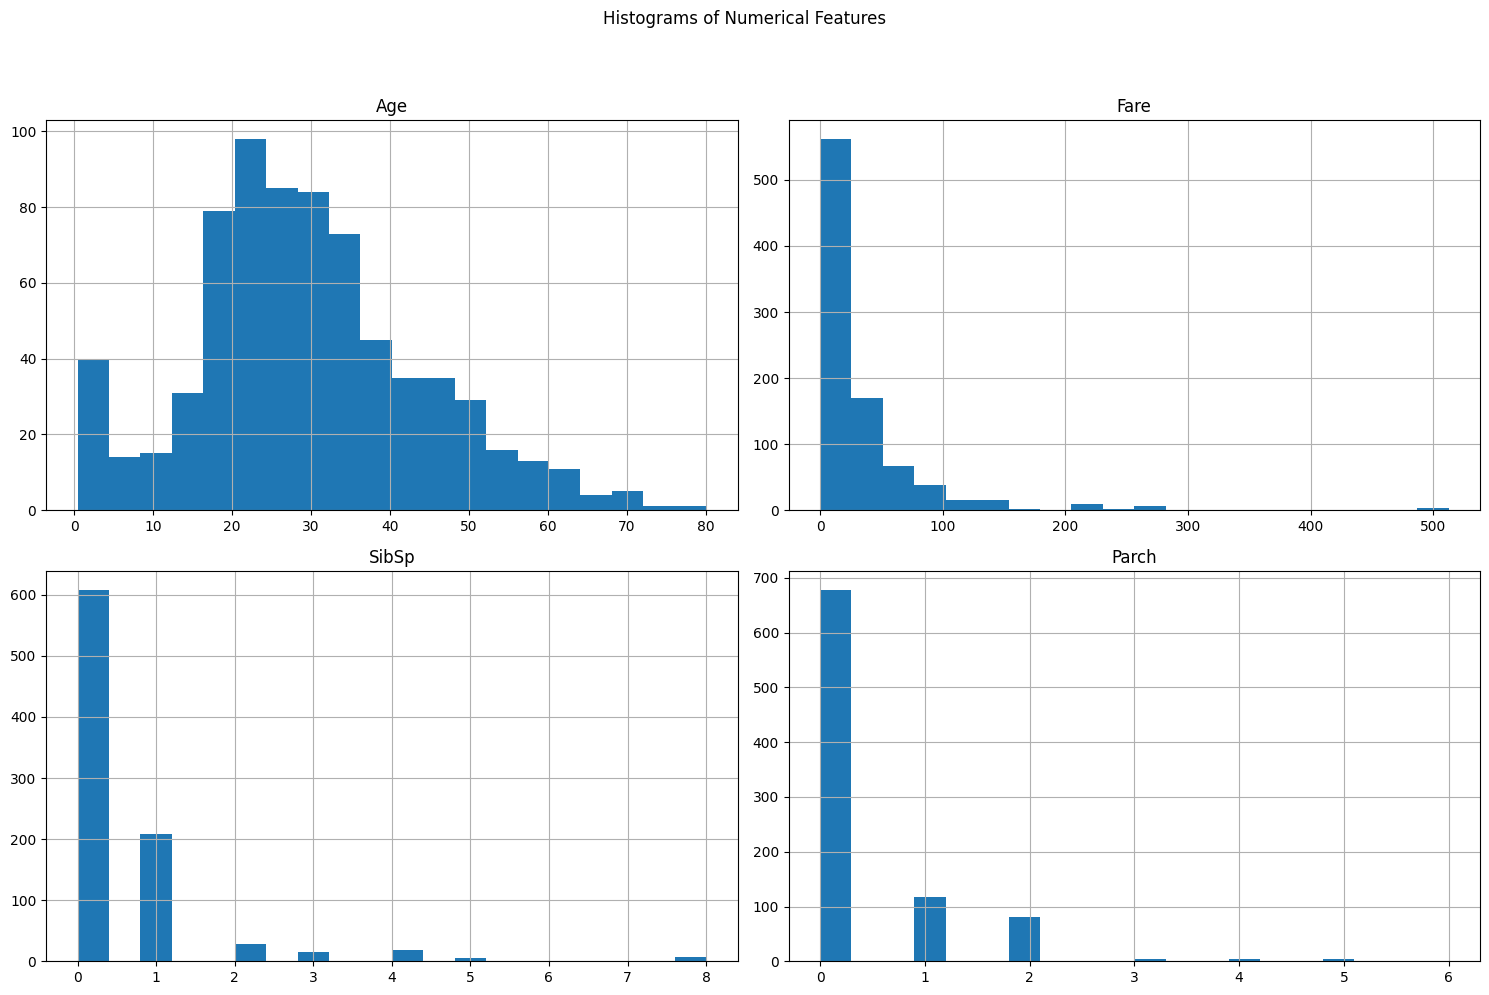

In [12]:
df_train[['Age', 'Fare', 'SibSp', 'Parch']].hist(bins=20, figsize=(15, 10))
plt.suptitle('Histograms of Numerical Features', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

### Boxplots of Numerical Features by Survival

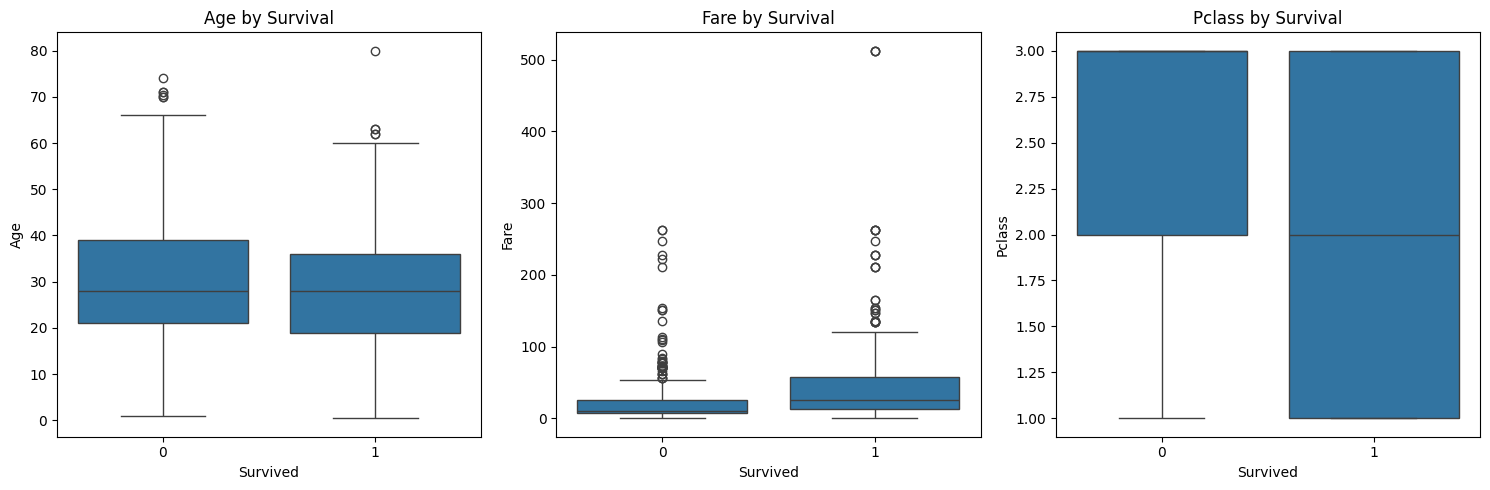

In [13]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.boxplot(x='Survived', y='Age', data=df_train)
plt.title('Age by Survival')

plt.subplot(1, 3, 2)
sns.boxplot(x='Survived', y='Fare', data=df_train)
plt.title('Fare by Survival')

plt.subplot(1, 3, 3)
sns.boxplot(x='Survived', y='Pclass', data=df_train)
plt.title('Pclass by Survival')

plt.tight_layout()
plt.show()

### Scatterplot: Age vs. Fare by Survival

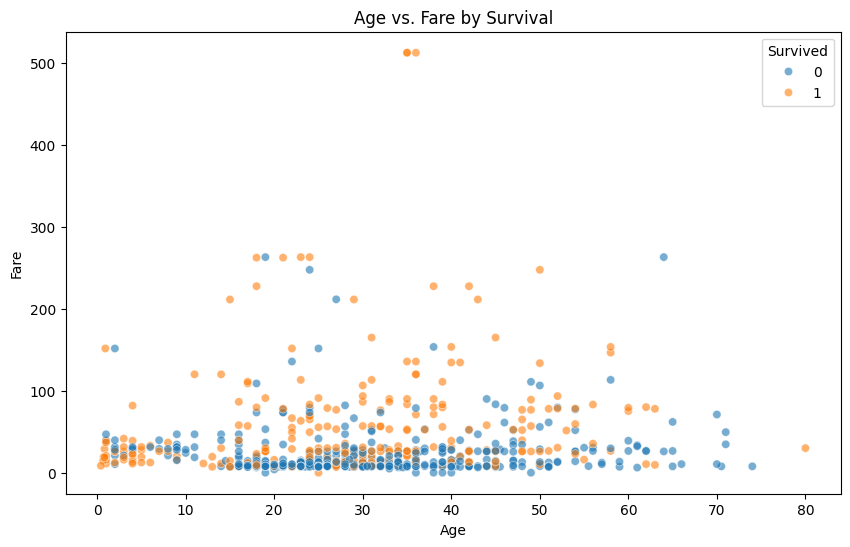

In [14]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=df_train, alpha=0.6)
plt.title('Age vs. Fare by Survival')
plt.show()